# 02 — Análisis Exploratorio de Datos (EDA)
## TFM: Predicción del comportamiento electoral presidencial en Colombia a nivel municipal

Este notebook consume el dataset maestro producido por `01_preprocesamiento.ipynb` / `src/preprocesamiento.py`.
No recalcula ni modifica ninguna columna del preprocesamiento — la Fase 1 está cerrada.

**Contenido de este notebook:**
1. Carga y verificación de continuidad con el dataset maestro
2. Distribución del target y confiabilidad electoral
3. Relación NBI × territorio (hallazgo central: heterogeneidad por departamento)
4. (Pendiente de completar en próximas sesiones: predictoras individuales, evolución temporal por departamento, panorama espacial)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sin rutas locales hardcodeadas: variable configurable al inicio
BASE_DIR = "."
RUTA_DATASET_MAESTRO = f"{BASE_DIR}/datos/procesados/dataset_maestro_electoral.csv"

df = pd.read_csv(RUTA_DATASET_MAESTRO, dtype={"divipola": str})
df["divipola"] = df["divipola"].str.zfill(5)

print(f"Dataset maestro: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()


Dataset maestro: 5605 filas x 23 columnas


,divipola,ano,departamento,municipio,votos_validos,votos_izquierda,pct_izquierda,votos_blanco,votos_nulos,votos_totales_emitidos,...,lag_pct_votos_blanco,lag_pct_izquierda_imputado,lag_pct_votos_blanco_imputado,peso_muestral,nbi_total,fuente_nbi,per_ocu,region_dane,baja_confiabilidad_electoral,valido_para_modelado
0,05001,2006,ANTIOQUIA,MEDELLIN,583228,107728.0,18.470992,14216.0,6237.0,603681.0,...,1.861362,0,0,1.0,12.424090,2005,64310.0,Andina,0,1
1,05002,2006,ANTIOQUIA,ABEJORRAL,5153,319.0,6.190569,79.0,62.0,5294.0,...,1.558442,0,0,1.0,33.851120,2005,64310.0,Andina,0,1
2,05004,2006,ANTIOQUIA,ABRIAQUI,688,83.0,12.063953,15.0,10.0,713.0,...,0.592593,0,0,1.0,28.538283,2005,64310.0,Andina,0,1
3,05021,2006,ANTIOQUIA,ALEJANDRIA,1471,99.0,6.730116,15.0,14.0,1500.0,...,4.307974,0,0,1.0,33.136095,2005,64310.0,Andina,0,1
4,05030,2006,ANTIOQUIA,AMAGA,6427,1486.0,23.121207,188.0,108.0,6723.0,...,1.454311,0,0,1.0,27.069045,2005,64310.0,Andina,0,1


## 1. Verificación de continuidad con la Fase 1

Antes de cualquier análisis, se comprueba que el dataset coincide con lo documentado en la bitácora
de preprocesamiento (filas por año, banderas de calidad). Esto NO reabre ninguna decisión de la
Fase 1 — es solo una verificación de que partimos del dataset correcto.

In [2]:
print("Filas por año:")
print(df["ano"].value_counts().sort_index())

print("\nFilas con baja_confiabilidad_electoral=1:", (df["baja_confiabilidad_electoral"] == 1).sum())
print("Filas con valido_para_modelado=0:", (df["valido_para_modelado"] == 0).sum())
print("Filas por region_dane:")
print(df["region_dane"].value_counts())


Filas por año:
ano
2006    1118
2010    1122
2014    1122
2018    1122
2022    1121
Name: count, dtype: int64

Filas con baja_confiabilidad_electoral=1: 21
Filas con valido_para_modelado=0: 1
Filas por region_dane:
region_dane
Andina       3145
Caribe        982
Pacifica      889
Orinoquia     295
Amazonia      294
Name: count, dtype: int64


## 2. Distribución del target y confiabilidad electoral

`baja_confiabilidad_electoral=1` marca municipios-año con menos de 30 votos totales emitidos
(ver bitácora de Fase 1, sección 27.3). Es importante distinguir este grupo al analizar valores
extremos del target: sin esta distinción, cualquier "top N de municipios anómalos" quedaría
dominado por ruido estadístico de electorados ínfimos, no por señal real de posible captura
territorial del voto — esto protege directamente la credibilidad del futuro mapa de anomalías
en la aplicación de Streamlit.

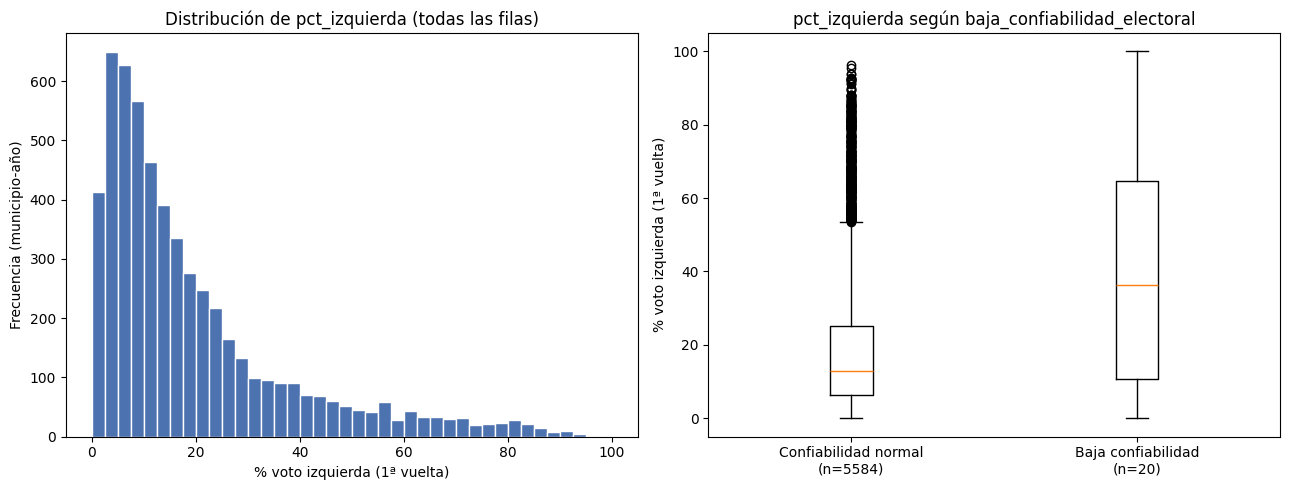

count    5584.000000
mean       19.381450
std        18.684479
min         0.000000
25%         6.370441
50%        13.005242
75%        25.212640
max        96.206662
Name: pct_izquierda, dtype: float64
count     20.000000
mean      40.776845
std       32.050449
min        0.000000
25%       10.714286
50%       36.397059
75%       64.583333
max      100.000000
Name: pct_izquierda, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df["pct_izquierda"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribución de pct_izquierda (todas las filas)")
axes[0].set_xlabel("% voto izquierda (1ª vuelta)")
axes[0].set_ylabel("Frecuencia (municipio-año)")

datos_confiables = df.loc[df["baja_confiabilidad_electoral"] == 0, "pct_izquierda"].dropna()
datos_baja_confiabilidad = df.loc[df["baja_confiabilidad_electoral"] == 1, "pct_izquierda"].dropna()
axes[1].boxplot(
    [datos_confiables, datos_baja_confiabilidad],
    tick_labels=[
        f"Confiabilidad normal\n(n={len(datos_confiables)})",
        f"Baja confiabilidad\n(n={len(datos_baja_confiabilidad)})",
    ],
)
axes[1].set_title("pct_izquierda según baja_confiabilidad_electoral")
axes[1].set_ylabel("% voto izquierda (1ª vuelta)")

plt.tight_layout()
plt.savefig(f"{BASE_DIR}/notebooks/figuras/eda_01_target_confiabilidad.png", dpi=130)
plt.show()

print(datos_confiables.describe())
print(datos_baja_confiabilidad.describe())


**Candidato a la app (Streamlit, Página 3 - Mapa de anomalías):** este boxplot, o una versión
refinada, justifica por qué el mapa de residuos debe tratar aparte los municipios de baja
confiabilidad electoral, en vez de mezclarlos con el resto en el ranking de anomalías.

## 3. NBI × territorio — heterogeneidad por departamento

La correlación nacional entre NBI municipal y % de voto de izquierda es prácticamente nula
(~0.03). Esto NO significa que el NBI no importe: significa que la relación cambia de signo
según el departamento, y esas señales opuestas se cancelan al agregar a nivel país (y se
diluyen, aunque menos, incluso al agregar a las 6 regiones naturales oficiales del DANE).

La heterogeneidad real vive a nivel **departamento**, no a nivel región. Ver bitácora de
Fase 2 (sección 4) para el detalle completo del proceso y las cautelas metodológicas.

In [4]:
print("Correlación NBI-voto, nacional:", round(df["pct_izquierda"].corr(df["nbi_total"]), 3))

corr_por_departamento = (
    df.groupby("departamento")
    .apply(lambda g: g["pct_izquierda"].corr(g["nbi_total"]) if g["pct_izquierda"].notna().sum() > 5 else np.nan,
           include_groups=False)
    .sort_values()
)
print("\nCorrelación NBI-voto por departamento (ordenado):")
print(corr_por_departamento)


Correlación NBI-voto, nacional: 0.026

Correlación NBI-voto por departamento (ordenado):
departamento
BOYACA                                                    -0.520329
CUNDINAMARCA                                              -0.475896
ATLANTICO                                                 -0.444935
MAGDALENA                                                 -0.438498
SUCRE                                                     -0.405988
VALLE DEL CAUCA                                           -0.379669
SANTANDER                                                 -0.366222
BOLIVAR                                                   -0.361908
HUILA                                                     -0.360279
CORDOBA                                                   -0.344139
CASANARE                                                  -0.330758
ARCHIPIELAGO DE SAN ANDRES PROVIDENCIA Y SANTA CATALINA   -0.310224
CESAR                                                     -0.255750
QUINDIO       

Correlación NBI-voto por región DANE oficial:
region_dane
Caribe      -0.330418
Andina      -0.188245
Amazonia    -0.095973
Pacifica    -0.092739
Orinoquia    0.075477
dtype: float64


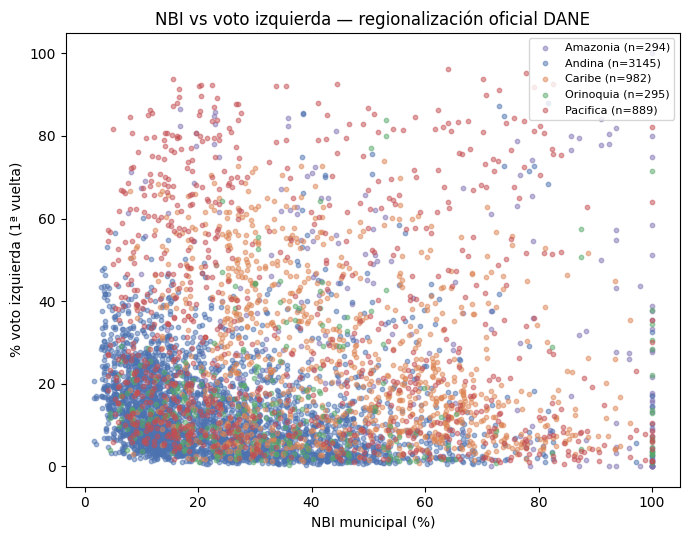

In [5]:
corr_por_region = (
    df.groupby("region_dane")
    .apply(lambda g: g["pct_izquierda"].corr(g["nbi_total"]), include_groups=False)
    .sort_values()
)
print("Correlación NBI-voto por región DANE oficial:")
print(corr_por_region)

fig, ax = plt.subplots(figsize=(7, 5.5))
colores = {"Andina": "#4C72B0", "Caribe": "#DD8452", "Pacifica": "#C44E52",
           "Orinoquia": "#55A868", "Amazonia": "#8172B2"}
for region, grupo in df.groupby("region_dane"):
    ax.scatter(grupo["nbi_total"], grupo["pct_izquierda"], s=10, alpha=0.5,
               label=f"{region} (n={len(grupo)})", color=colores.get(region))
ax.set_xlabel("NBI municipal (%)")
ax.set_ylabel("% voto izquierda (1ª vuelta)")
ax.set_title("NBI vs voto izquierda — regionalización oficial DANE")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/notebooks/figuras/eda_02_nbi_region_dane.png", dpi=130)
plt.show()


### Comprobación de robustez frente a electorados ínfimos

Antes de dar por válida la heterogeneidad por departamento, se verifica que no sea un artefacto
de los municipios de electorado muy pequeño (`baja_confiabilidad_electoral=1`): se recalculan las
correlaciones ponderando por `peso_muestral` y excluyendo esas filas.

In [6]:
def correlacion_ponderada(x, y, w):
    mascara = x.notna() & y.notna() & w.notna()
    x, y, w = x[mascara], y[mascara], w[mascara]
    media_x = np.average(x, weights=w)
    media_y = np.average(y, weights=w)
    covarianza = np.average((x - media_x) * (y - media_y), weights=w)
    var_x = np.average((x - media_x) ** 2, weights=w)
    var_y = np.average((y - media_y) ** 2, weights=w)
    return covarianza / np.sqrt(var_x * var_y)

departamentos_interes = [
    "VICHADA", "GUAINIA", "VAUPES", "AMAZONAS", "GUAVIARE", "CAQUETA", "ARAUCA", "META",
    "NORTE DE SANTANDER", "BOYACA", "CUNDINAMARCA", "SANTANDER", "ATLANTICO",
]
filas = []
for depto in departamentos_interes:
    grupo = df[df["departamento"] == depto]
    corr_cruda = grupo["pct_izquierda"].corr(grupo["nbi_total"])
    corr_ponderada = correlacion_ponderada(grupo["nbi_total"], grupo["pct_izquierda"], grupo["peso_muestral"])
    grupo_excl = grupo[grupo["baja_confiabilidad_electoral"] == 0]
    corr_excl = grupo_excl["pct_izquierda"].corr(grupo_excl["nbi_total"]) if len(grupo_excl) > 5 else np.nan
    filas.append([depto, len(grupo), grupo["baja_confiabilidad_electoral"].sum(),
                  corr_cruda, corr_ponderada, corr_excl])

resultado = pd.DataFrame(
    filas,
    columns=["departamento", "n", "n_baja_confiabilidad", "corr_cruda", "corr_ponderada", "corr_excl_baja_confiab"],
)
resultado


,departamento,n,n_baja_confiabilidad,corr_cruda,corr_ponderada,corr_excl_baja_confiab
0,VICHADA,20,0,0.219561,0.219561,0.219561
1,GUAINIA,44,10,-0.052732,-0.071631,-0.204529
2,VAUPES,30,3,-0.231209,-0.224712,-0.187497
3,AMAZONAS,55,8,-0.006253,-0.108629,-0.125835
4,GUAVIARE,20,0,-0.145630,-0.145826,-0.145630
5,CAQUETA,80,0,0.140809,0.140809,0.140809
6,ARAUCA,35,0,0.284271,0.284271,0.284271
7,META,145,0,0.122502,0.120339,0.122502
8,NORTE DE SANTANDER,200,0,0.356257,0.356257,0.356257
9,BOYACA,615,0,-0.520329,-0.521199,-0.520329


**Conclusión:** en los departamentos sin ninguna fila de baja confiabilidad, las tres versiones
de la correlación son prácticamente idénticas. Donde hay movimiento (Guainía, Vaupés, Amazonas)
la correlación se vuelve más negativa al limpiar el ruido, nunca positiva — la heterogeneidad de
signo por departamento es un hallazgo robusto, no un artefacto de electorados ínfimos.

**Pendiente de completar en próximas sesiones (ver bitácora de Fase 2, sección 7):**
distribución individual de predictoras, evolución temporal por departamento, panorama espacial
descriptivo, tipologías de municipio.

## 4. Distribución individual de predictoras

Se analizan `nbi_total`, `per_ocu`, `lag_pct_izquierda` y `pct_votos_blanco` (esta última es
descriptiva, no predictora — ver `COLUMNAS_DESCRIPTIVAS_NO_PREDICTORAS` en `preprocesamiento.py`).
Las funciones de graficado/resumen viven en `src/eda_utils.py`, siguiendo la misma disciplina que
la Fase 1: el notebook llama a las funciones e interpreta resultados, no repite lógica de
graficado inline.

In [7]:
import sys
sys.path.insert(0, BASE_DIR)
from src.eda_utils import (
    resumen_estadistico_predictoras, graficar_histogramas_predictoras,
    comparar_nbi_por_fuente, verificar_impacto_imputacion_lag,
    graficar_relacion_predictora_target,
)

columnas_predictoras_desc = ["nbi_total", "per_ocu", "lag_pct_izquierda", "pct_votos_blanco"]
resumen_estadistico_predictoras(df, columnas_predictoras_desc)


,count,mean,std,min,25%,50%,75%,max,pct_nulos
nbi_total,5605.0,31.882316,22.083333,1.591327,13.987424,26.043788,44.844693,100.000000,0.000000
per_ocu,5605.0,14928.114362,17584.001363,0.000000,1323.000000,6270.000000,26319.000000,64755.000000,0.000000
lag_pct_izquierda,5605.0,13.300154,14.377476,0.000000,4.031263,8.182750,16.966825,100.000000,0.000000
pct_votos_blanco,5604.0,2.078939,1.724767,0.000000,1.076521,1.660070,2.511380,51.733627,0.017841


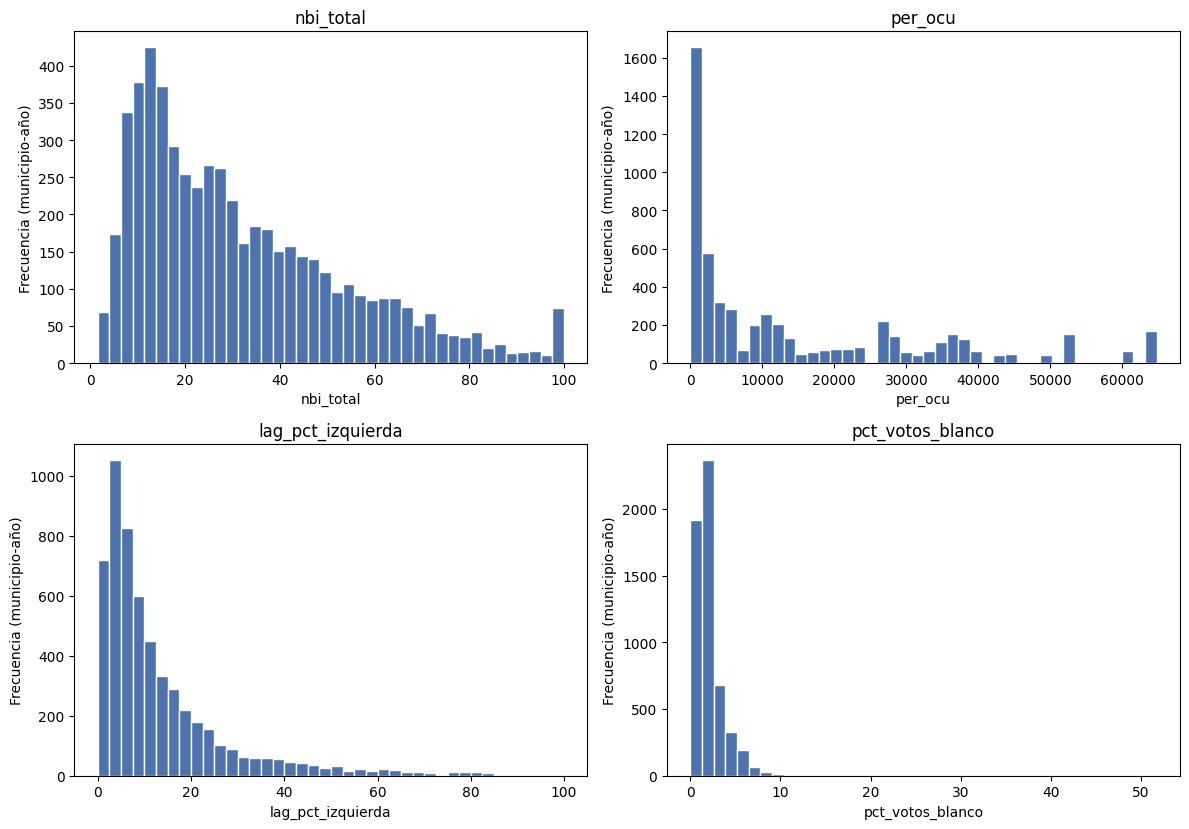

In [8]:
# Diagnostico exploratorio, no reutilizable en la app/memoria -> solo embebido
graficar_histogramas_predictoras(df, columnas_predictoras_desc)


**Lectura:** `nbi_total` tiene una distribución bimodal leve (efecto de mezclar censo 2005 y 2018,
ver siguiente celda). `per_ocu` está muy sesgado a la derecha (mediana 6.270, máximo 64.755;
percentil 90 en 39.632) — candidato a transformación logarítmica si entra al modelo, decisión que
corresponde al Chat 5, no a este EDA. `lag_pct_izquierda` reproduce la misma asimetría que el
propio target (coherente, es el target del año anterior). `pct_votos_blanco` tiene una fila nula
(La Guadalupe 2006, ya documentado en la Fase 1 como `valido_para_modelado=0`).

### 4.1 NBI municipal: heterogeneidad temporal por cambio de censo (limitación ya documentada)

El NBI proviene de 2 censos distintos según el año electoral (`fuente_nbi`: Censo 2005 para
1998-2010, Censo 2018 para 2014-2022 — decisión ya cerrada en la Fase 1, no se reabre aquí). Se
documenta la magnitud de esa heterogeneidad temporal.

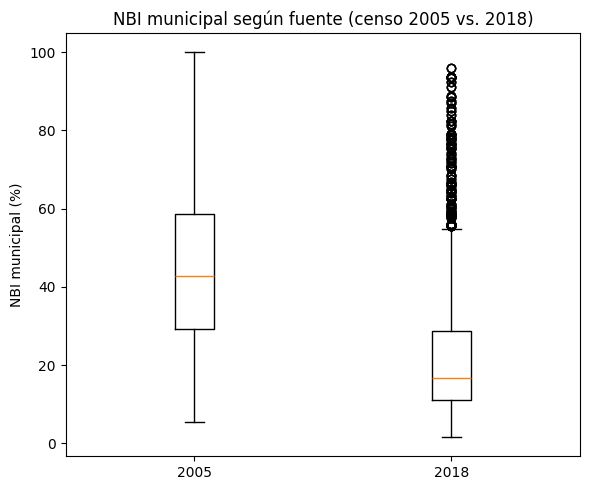

,count,mean,std,min,25%,50%,75%,max
fuente_nbi,,,,,,,,
2005,2240.0,45.352470,21.106715,5.430319,29.089494,42.847246,58.610308,100.000000
2018,3365.0,22.915556,17.738277,1.591327,10.962963,16.748548,28.666952,95.963756


In [9]:
# Diagnostico exploratorio, no reutilizable en la app/memoria -> solo embebido
comparar_nbi_por_fuente(df)


**Lectura:** el NBI medio del Censo 2005 (45,4%) prácticamente duplica al de 2018 (22,9%) — refleja
la reducción real de la pobreza estructural en Colombia en esos 13 años, pero también significa que
parte de la caída de NBI que verá el modelo entre elecciones de distintos periodos es un efecto de
cambio de instrumento de medición, no solo de mejora real. Esto ya está anotado como limitación en
el prompt de contexto del proyecto («NBI e IPM... el NBI es el antecedente histórico del IPM»); este
gráfico cuantifica la magnitud del salto para poder citarlo con un número concreto en la memoria.

### 4.2 Impacto de la imputación del lag

`lag_pct_izquierda_imputado=1` marca los municipios sin fila en la elección anterior (imputados con
la media departamental del año, ver Fase 1). Se compara la distribución del lag entre filas
imputadas y reales, para que el Chat 5 sepa si la imputación desplaza el lag de forma relevante.

In [10]:
verificar_impacto_imputacion_lag(df)


,count,mean,std,min,25%,50%,75%,max
lag_pct_izquierda_imputado,,,,,,,,
lag_real,5582.0,13.316566,14.387626,0.000000,4.032646,8.190484,16.970924,100.000000
lag_imputado,23.0,9.317101,11.197516,1.484163,3.763458,5.240933,9.876653,44.656323


**Lectura:** las 23 filas imputadas tienen una media de lag más baja (9,3%) que las filas con lag
real (13,3%) — diferencia moderada, no dramática, y afecta a menos del 0,5% de las filas. No parece
un problema grave para el modelado, pero queda documentado por si el Chat 5 quiere excluir estas
filas de algún análisis de sensibilidad.

### 4.3 Relación de cada predictora con el target

Ya se documentó en detalle la relación NBI-target (sección 3). Aquí se completa con `per_ocu` y
`lag_pct_izquierda` (`pct_votos_blanco` es descriptiva, se incluye solo por completitud del EDA).

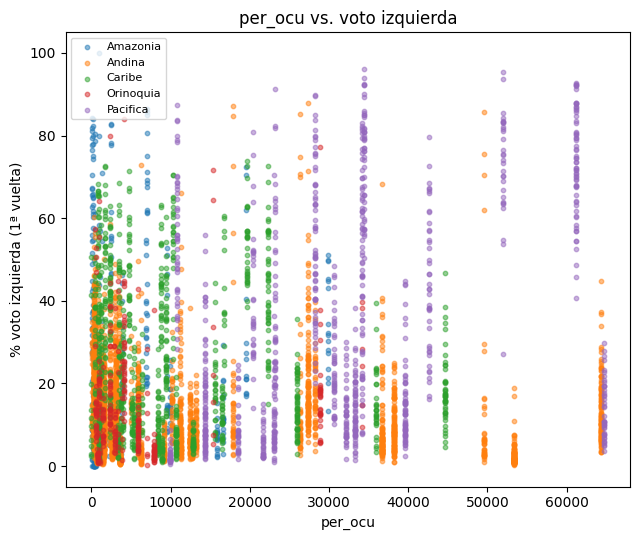

Correlación PER_OCU - voto izquierda: 0.134


In [11]:
# Diagnostico exploratorio, no reutilizable en la app/memoria -> solo embebido
corr_per_ocu = graficar_relacion_predictora_target(df, "per_ocu", columna_color="region_dane")
print("Correlación PER_OCU - voto izquierda:", round(corr_per_ocu, 3))


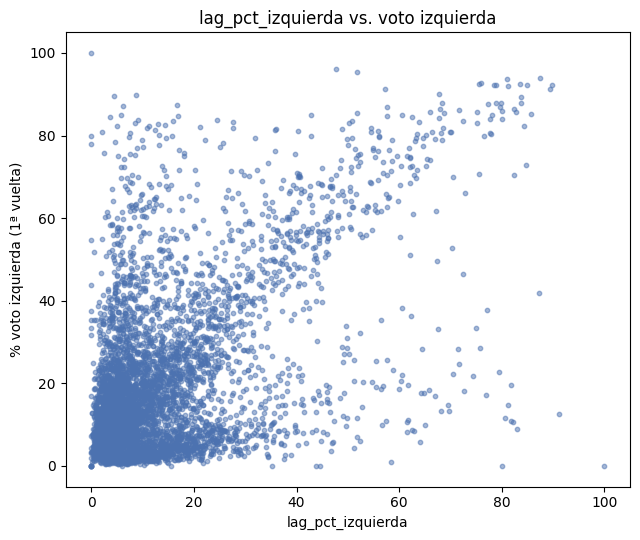

Correlación lag_pct_izquierda - voto izquierda: 0.542


In [12]:
# Diagnostico exploratorio, no reutilizable en la app/memoria -> solo embebido
corr_lag = graficar_relacion_predictora_target(df, "lag_pct_izquierda")
print("Correlación lag_pct_izquierda - voto izquierda:", round(corr_lag, 3))


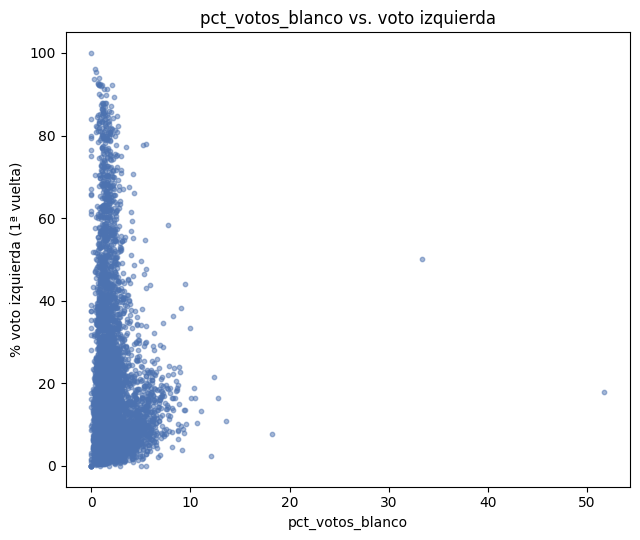

Correlación pct_votos_blanco (descriptiva) - voto izquierda: -0.072


In [13]:
# Diagnostico exploratorio, no reutilizable en la app/memoria -> solo embebido
corr_blanco = graficar_relacion_predictora_target(df, "pct_votos_blanco")
print("Correlación pct_votos_blanco (descriptiva) - voto izquierda:", round(corr_blanco, 3))


**Lectura:**
- `lag_pct_izquierda` (0,54) es, con diferencia, la relación más fuerte con el target — coherente
  con la hipótesis de inercia electoral planteada en el prompt de contexto. Esto es exactamente la
  razón por la que el proyecto exige reportar el modelo con y sin lag (ver Diseño metodológico):
  una correlación de 0,54 puede absorber buena parte de la varianza que se quiere atribuir a NBI/
  conflicto.
- `per_ocu` (0,13) es débil-moderada y positiva — más intensidad de conflicto se asocia con algo
  más de voto de izquierda, en promedio nacional. Dado lo aprendido en la sección 3 sobre NBI, es
  razonable esperar que esta relación también sea heterogénea por departamento — no se explora ese
  detalle aquí para no repetir el mismo análisis dos veces; queda anotado como línea abierta para
  el Chat 5 si se decide construir una interacción PER_OCU×territorio.
- `pct_votos_blanco` (−0,07) es prácticamente nula — no aporta señal relevante como variable
  descriptiva del EDA, más allá de servir de proxy de participación/descontento (rol ya documentado
  en la Fase 1).

**Pendiente (ver bitácora de Fase 2, sección 7):** evolución temporal por departamento, panorama
espacial descriptivo, tipologías de municipio.